In [1]:
pip install pandas numpy nltk scikit-learn flask joblib

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import re
import string
import joblib
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Download NLTK Data
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

print("All Libraries Imported Successfully!")

[nltk_data] Downloading package punkt to C:\Users\rohan
[nltk_data]     bhowmik\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\rohan
[nltk_data]     bhowmik\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\rohan
[nltk_data]     bhowmik\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\rohan
[nltk_data]     bhowmik\AppData\Roaming\nltk_data...


All Libraries Imported Successfully!


[nltk_data]   Package omw-1.4 is already up-to-date!


In [3]:
# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("IMDB_Dataset_CLEANED.csv")

print("Dataset Loaded Successfully!")

print("\nFirst Five Rows:")
display(df.head())

print("\nFirst Five Rows:")
display(df.tail())

print("\nDataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSentiment Distribution:")
print(df["sentiment"].value_counts())

Dataset Loaded Successfully!

First Five Rows:


,review,sentiment
0,"$25,000 Pyramid Clues: Deep Blue Sea. Tremors....",negative
1,0.5/10. This movie has absolutely nothing good...,negative
2,"0*'s Christian Slater, Tara Reid, Stephen Dorf...",negative
3,"102 Dalmatians (2000, Dir. Kevin Lima) <br /><...",negative
4,102 DALMATIANS [Walt Disney]: I wasn't a fan o...,negative



First Five Rows:


,review,sentiment
49391,It seems that it is becoming fashionable to ri...,positive
49392,"This is, without a shadow of a doubt, one of t...",positive
49393,Given the low budget and production limitation...,positive
49394,If Christopher Nolan had made Memento before F...,positive
49395,THE LATE SHIFT was an interesting made for HBO...,positive



Dataset Shape:
(49396, 2)

Missing Values:
review       0
sentiment    0
dtype: int64

Sentiment Distribution:
sentiment
negative    24698
positive    24698
Name: count, dtype: int64


In [4]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def preprocess_text(text):

    text = text.lower()

    text = re.sub(r"<.*?>", " ", text)

    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    text = re.sub(r"\d+", " ", text)

    text = text.translate(str.maketrans("", "", string.punctuation))

    text = re.sub(r"\s+", " ", text).strip()

    words = nltk.word_tokenize(text)

    cleaned_words = []

    for word in words:

        if word not in stop_words:

            cleaned_words.append(lemmatizer.lemmatize(word))

    return " ".join(cleaned_words)

df["clean_review"] = df["review"].apply(preprocess_text)

print("Text Preprocessing Completed!")

display(df[["review", "clean_review"]].head())

Text Preprocessing Completed!


,review,clean_review
0,"$25,000 Pyramid Clues: Deep Blue Sea. Tremors....",pyramid clue deep blue sea tremor slither eigh...
1,0.5/10. This movie has absolutely nothing good...,movie absolutely nothing good acting among wor...
2,"0*'s Christian Slater, Tara Reid, Stephen Dorf...",christian slater tara reid stephen dorff frank...
3,"102 Dalmatians (2000, Dir. Kevin Lima) <br /><...",dalmatian dir kevin lima believed cured cruell...
4,102 DALMATIANS [Walt Disney]: I wasn't a fan o...,dalmatian walt disney wasnt fan previous insta...


In [5]:

df["label"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

print("Labels Converted Successfully!\n")

display(df[["sentiment", "label"]].head())

# ==========================================
# TF-IDF VECTORIZATION
# ==========================================

vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.8
)

X = vectorizer.fit_transform(df["clean_review"])

y = df["label"]

print("\nTF-IDF Feature Matrix Created Successfully!")

print("\nFeature Matrix Shape:", X.shape)

print("Target Variable Shape:", y.shape)

print("\nTotal Features:", len(vectorizer.get_feature_names_out()))

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain-Test Split Completed Successfully!")

print("\nTraining Data")
print("X_train :", X_train.shape)
print("y_train :", y_train.shape)

print("\nTesting Data")
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

Labels Converted Successfully!



,sentiment,label
0,negative,0
1,negative,0
2,negative,0
3,negative,0
4,negative,0



TF-IDF Feature Matrix Created Successfully!

Feature Matrix Shape: (49396, 5000)
Target Variable Shape: (49396,)

Total Features: 5000

Train-Test Split Completed Successfully!

Training Data
X_train : (39516, 5000)
y_train : (39516,)

Testing Data
X_test : (9880, 5000)
y_test : (9880,)


In [6]:
print("=" * 60)
print("TRAINING MACHINE LEARNING MODEL")
print("=" * 60)

model = MultinomialNB()

model.fit(X_train, y_train)

print("\nModel Trained Successfully!")

y_pred = model.predict(X_test)

print("\nPredictions Generated Successfully!")

print("\nSample Predictions")
print("=" * 60)

for i in range(10):

    actual = "Positive" if y_test.iloc[i] == 1 else "Negative"

    predicted = "Positive" if y_pred[i] == 1 else "Negative"

    print(f"\nReview {i+1}")

    print(f"Actual Sentiment    : {actual}")

    print(f"Predicted Sentiment : {predicted}")

    print("-" * 50)

print("\nMachine Learning Model Training Completed Successfully!")

TRAINING MACHINE LEARNING MODEL

Model Trained Successfully!

Predictions Generated Successfully!

Sample Predictions

Review 1
Actual Sentiment    : Positive
Predicted Sentiment : Negative
--------------------------------------------------

Review 2
Actual Sentiment    : Negative
Predicted Sentiment : Negative
--------------------------------------------------

Review 3
Actual Sentiment    : Negative
Predicted Sentiment : Positive
--------------------------------------------------

Review 4
Actual Sentiment    : Negative
Predicted Sentiment : Negative
--------------------------------------------------

Review 5
Actual Sentiment    : Negative
Predicted Sentiment : Negative
--------------------------------------------------

Review 6
Actual Sentiment    : Negative
Predicted Sentiment : Negative
--------------------------------------------------

Review 7
Actual Sentiment    : Positive
Predicted Sentiment : Positive
--------------------------------------------------

Review 8
Actual Sent

In [7]:
print("=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

accuracy = accuracy_score(y_test, y_pred)

print(f"\nModel Accuracy : {accuracy * 100:.2f}%")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Positive"]
))

# Confusion Matrix
print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

cm = confusion_matrix(y_test, y_pred)

print(cm)

print("\nTrue Negative :", cm[0][0])
print("False Positive:", cm[0][1])
print("False Negative:", cm[1][0])
print("True Positive :", cm[1][1])

joblib.dump(model, "model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

print("\nModel Saved Successfully!")
print("Generated Files:")
print("✓ model.pkl")
print("✓ vectorizer.pkl")

def predict_sentiment(review):

    clean_review = preprocess_text(review)

    review_vector = vectorizer.transform([clean_review])

    prediction = model.predict(review_vector)[0]

    probability = model.predict_proba(review_vector)[0]

    confidence = round(max(probability) * 100, 2)

    sentiment = "Positive" if prediction == 1 else "Negative"

    return sentiment, confidence

sample_reviews = [

    "This movie was absolutely amazing. I loved every minute of it.",

    "Worst movie ever. Waste of time.",

    "The acting was fantastic and the story was very interesting.",

    "Terrible experience. I will never watch it again.",

    "It was okay. Not the best but not the worst."

]

print("\n" + "=" * 60)
print("CUSTOM REVIEW PREDICTIONS")
print("=" * 60)

for i, review in enumerate(sample_reviews, start=1):

    sentiment, confidence = predict_sentiment(review)

    print(f"\nReview {i}")
    print("-" * 70)
    print("Review      :", review)
    print("Prediction  :", sentiment)
    print(f"Confidence  : {confidence:.2f}%")

print("\n" + "=" * 60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 60)
print("NLP Sentiment Analysis using Machine Learning")
print("Algorithm : Multinomial Naive Bayes")
print("Feature Extraction : TF-IDF")
print(f"Final Accuracy : {accuracy * 100:.2f}%")

MODEL EVALUATION

Model Accuracy : 85.40%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.86      0.84      0.85      4940
    Positive       0.85      0.86      0.86      4940

    accuracy                           0.85      9880
   macro avg       0.85      0.85      0.85      9880
weighted avg       0.85      0.85      0.85      9880


CONFUSION MATRIX
[[4172  768]
 [ 674 4266]]

True Negative : 4172
False Positive: 768
False Negative: 674
True Positive : 4266

Model Saved Successfully!
Generated Files:
✓ model.pkl
✓ vectorizer.pkl

CUSTOM REVIEW PREDICTIONS

Review 1
----------------------------------------------------------------------
Review      : This movie was absolutely amazing. I loved every minute of it.
Prediction  : Positive
Confidence  : 69.59%

Review 2
----------------------------------------------------------------------
Review      : Worst movie ever. Waste of time.
Prediction  : Negative
Confidence  : 96.39%

Revie

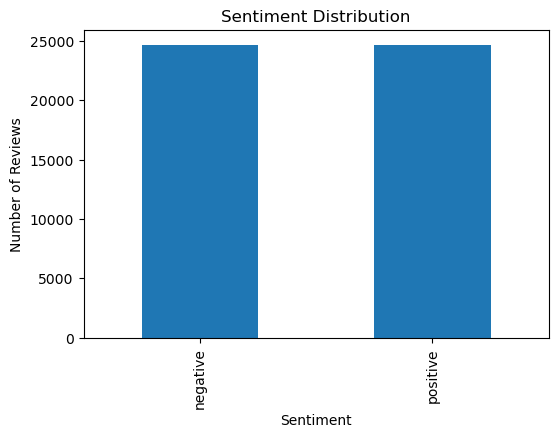

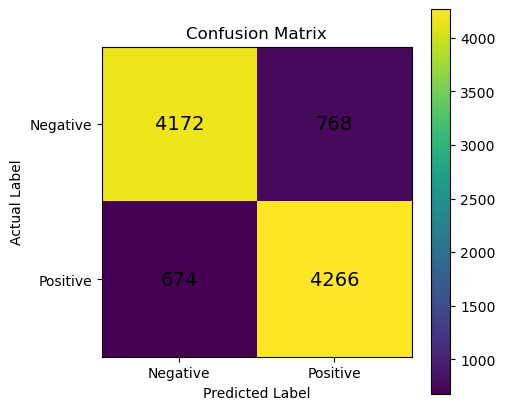

In [8]:

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

df["sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Number of Reviews")

plt.show()

# ------------------------------------------
# Confusion Matrix
# ------------------------------------------

plt.figure(figsize=(5,5))

plt.imshow(cm, interpolation="nearest")

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks([0,1], ["Negative","Positive"])

plt.yticks([0,1], ["Negative","Positive"])

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 fontsize=14)

plt.show()

In [9]:
print("="*60)
print("PROJECT SUMMARY")
print("="*60)

print("""
Project Name :
NLP Sentiment Analysis using Machine Learning

Algorithm Used :
• Multinomial Naive Bayes

Feature Extraction :
• TF-IDF Vectorizer

Natural Language Processing :
• Tokenization
• Stopword Removal
• Lemmatization

Model Accuracy :
{:.2f}%

Outcome :
The model successfully classifies movie reviews
into Positive and Negative sentiments.

Future Improvements :
• Use BERT / DistilBERT
• Multi-class Sentiment Analysis
• Emotion Detection
• Real-time Web Deployment
""".format(accuracy*100))

print("="*60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*60)

PROJECT SUMMARY

Project Name :
NLP Sentiment Analysis using Machine Learning

Algorithm Used :
• Multinomial Naive Bayes

Feature Extraction :
• TF-IDF Vectorizer

Natural Language Processing :
• Tokenization
• Stopword Removal
• Lemmatization

Model Accuracy :
85.40%

Outcome :
The model successfully classifies movie reviews
into Positive and Negative sentiments.

Future Improvements :
• Use BERT / DistilBERT
• Multi-class Sentiment Analysis
• Emotion Detection
• Real-time Web Deployment

PROJECT COMPLETED SUCCESSFULLY


count    49396.000000
mean      1310.542331
std        990.722799
min         32.000000
25%        699.000000
50%        971.000000
75%       1591.250000
max      13704.000000
Name: review_length, dtype: float64


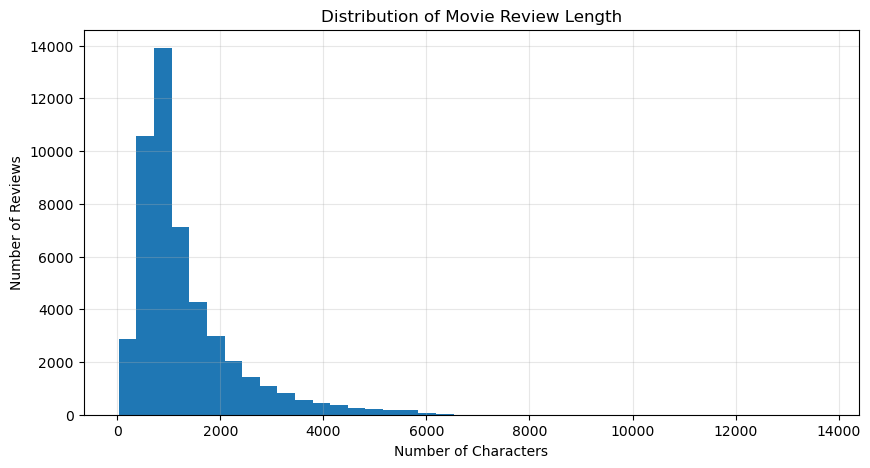

In [10]:
import matplotlib.pyplot as plt

df["review_length"] = df["review"].apply(len)

print(df["review_length"].describe())

plt.figure(figsize=(10,5))

plt.hist(df["review_length"], bins=40)

plt.title("Distribution of Movie Review Length")

plt.xlabel("Number of Characters")

plt.ylabel("Number of Reviews")

plt.grid(alpha=0.3)

plt.show()

In [11]:
from collections import Counter

all_words = " ".join(df["clean_review"]).split()

common_words = Counter(all_words).most_common(20)

word_df = pd.DataFrame(common_words,
                       columns=["Word","Frequency"])

display(word_df)

,Word,Frequency
0,movie,99875
1,film,90559
2,one,53203
3,like,39552
4,time,29877
5,good,28739
6,character,27639
7,story,24493
8,even,24336
9,get,24244


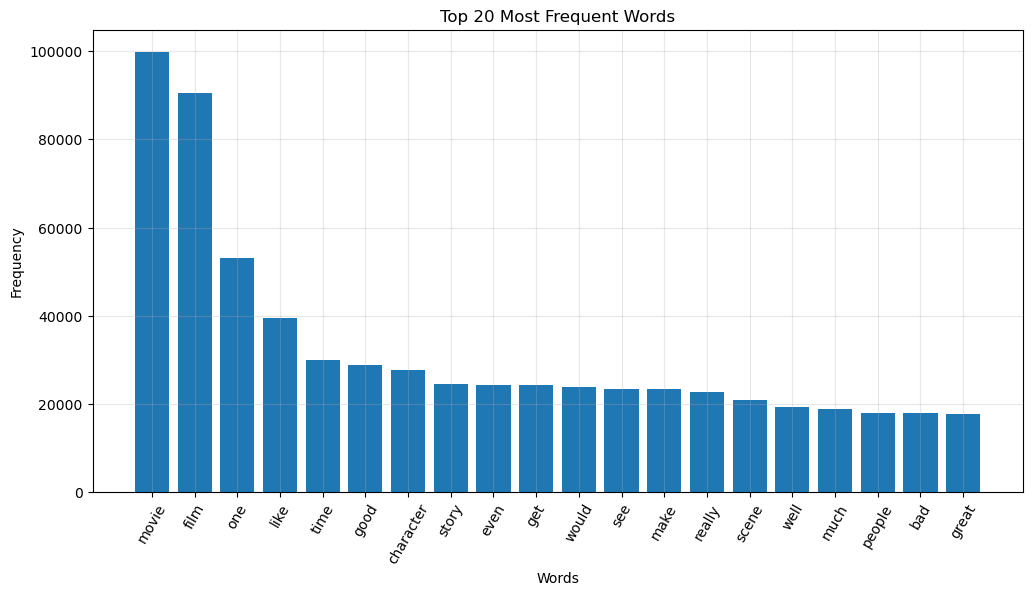

In [12]:
plt.figure(figsize=(12,6))

plt.bar(word_df["Word"],
        word_df["Frequency"])

plt.xticks(rotation=60)

plt.title("Top 20 Most Frequent Words")

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

In [13]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy")

print(f"{lr_accuracy*100:.2f}%")

Logistic Regression Accuracy
88.76%


In [14]:
comparison = pd.DataFrame({

    "Algorithm":[
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ],

    "Accuracy":[
        accuracy*100,
        lr_accuracy*100
    ]

})

display(comparison)

,Algorithm,Accuracy
0,Multinomial Naive Bayes,85.404858
1,Logistic Regression,88.755061


In [15]:
review = input("Enter Your Movie Review : ")

sentiment, confidence = predict_sentiment(review)

print("\nPrediction Result")

print("-------------------------")

print("Sentiment :", sentiment)

print(f"Confidence : {confidence:.2f}%")

Enter Your Movie Review :  good



Prediction Result
-------------------------
Sentiment : Positive
Confidence : 51.22%
